In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

Xtrain = pd.read_csv('/dcs/22/u2243582/cs310/Xtrainfeatnew.csv', index_col=0)
ytrain = pd.read_csv('/dcs/22/u2243582/cs310/ytrain.csv', index_col=0)
Xtest = pd.read_csv('/dcs/22/u2243582/cs310/Xtestfeatnew.csv', index_col=0)
ytest = pd.read_csv('/dcs/22/u2243582/cs310/ytest.csv', index_col=0)

X = pd.concat([Xtrain, Xtest])
y = pd.concat([ytrain, ytest])
y = y.values.ravel() # array instead of 1 column

In [14]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [15]:
pca = PCA(0.80) # keep 80% of the variance of the data
pca.fit(X)
Xtrain = pca.transform(X)

print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

Components: 6 Total explained variance: 0.8485759168090902


#### https://machinelearningmastery.com/nested-cross-validation-for-machine-learning-with-python/

In [28]:
cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = RandomForestRegressor(random_state=1)

    space = {
    'n_estimators': [25, 50, 100, 150, 200, 300],  
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'max_features': ['log2', 'sqrt', 1.0],
    'min_samples_leaf': [1, 5, 10, 25],
    'min_samples_split': [2, 10, 25, 50, 75, 100],
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
"Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
"Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
"Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
"Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
"Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
"Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
"R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

{'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 90}
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 60}
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 40}
Pearson Correlation: Mean = 0.7536488795558969, Std = 0.020248221867859673
Pearson P-value: Mean = 1.3788307822621297e-163, Std = 0.0
Spearman Correlation: Mean = 0.7429839118494286, Std = 0.023529766564792276
Spearman P-value: Mean = 2.1335363903745312e-156, Std = 4.2670727807480283e-156
Mean Absolute Error: Mean = 0.9927449202491798, Std = 0.03360915642788561
Variance of Errors: Mean = 1.6568288900521075, Std = 0.13675253591947403
R2: Mean = 0.56396

In [29]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.7206999512176135, 0.7466974329426471, 0.7807270338369351, 0.7671510703681598, 0.7529689094141288]
[0.7095126322128135, 0.7292644161091949, 0.7794242987399859, 0.7544423299932997, 0.7422758821918489]
[1.0431335554300771, 1.01798676807174, 0.9543636595779122, 0.9864661198945985, 0.961774498271572]
[1.904423561349637, 1.6594870232997518, 1.5043864533420948, 1.6536071984300522, 1.5622402138390035]
[0.5188043659253754, 0.5541393378740606, 0.600199651170403, 0.5814854907818681, 0.5652208373769878]


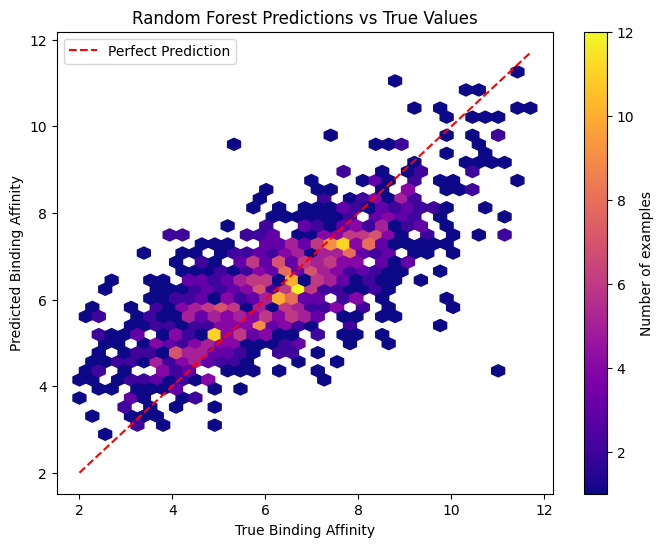

In [30]:
# Plot hexbin of true vs. predicted values
import matplotlib.pyplot as plt


# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("Random Forest Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()